In [1]:
import torch
from torch.utils.data import DataLoader
from src.load import MasterDataset, _worker_init_fn
from src.gen.gen import create_mesh
from pathlib import Path
import numpy as np
from src.io.hdf5_i import MasterReader
from src.viz.samples import (
    plot_topography,
    plot_density_contrast_3D_voxels,
    plot_gravity_measurements,
)
from src.transforms import make_transform

Available seeds: [0, 1, 2, 3, 4]


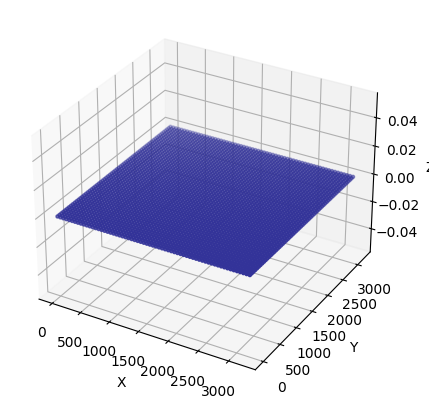

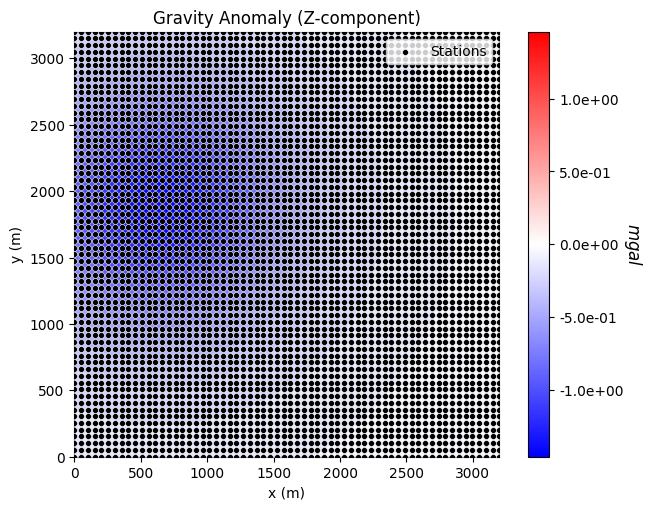

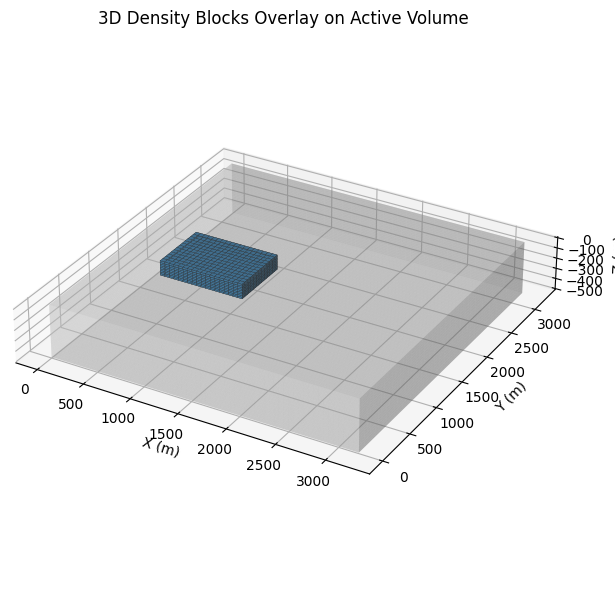

In [4]:
with MasterReader(Path("data/master.h5")) as mr:
    seeds = mr.list_seeds()
    print("Available seeds:", seeds[:5])   # show first 5
    sample = mr.read(seeds[4])
    gz = sample["gz"]
    true_model = sample["true_model"]
    ind_active = sample["ind_active"].astype(bool)
    receiver_locations = sample["receiver_locations"]
    plot_topography(receiver_locations)
    y = sample["gz"]
    true_model = sample["true_model"]
    plot_gravity_measurements(receiver_locations, y)
    full_model = np.zeros_like(ind_active, dtype=float)
    full_model[ind_active] = true_model
    blocks_mask = full_model > 0.0
    receiver_locations = np.flip(receiver_locations, axis=0)
    mesh = create_mesh(receiver_locations, n_xy=64, n_z=32, z_dom=1.6e3)
    plot_density_contrast_3D_voxels(mesh, ind_active, blocks_mask)

In [2]:
from src.load import MasterDataset, _worker_init_fn
from src.transforms import make_transform
from src.model import GravInvNet  # wherever your model lives


ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

net = GravInvNet()
x = ds[0][0]
x = x.unsqueeze(0)
y = net(x)
print(y.shape)  # torch.Size([2, 32, 64, 64])

torch.Size([1, 32, 64, 64])


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")